In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

In [2]:
#Now, lOadding the dataset
file_name = "delhi_ncr_aqi_dataset.csv"
df = pd.read_csv(file_name)

print("Data Loaded Successfully")

Data Loaded Successfully


In [3]:
df.head() #Displays first 5 rows of the dataset

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


In [4]:
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns") # Prints total number of rows and columns in the dataset
print(f"\nDate Range: {df['datetime'].min()} to {df['datetime'].max()}") # Displays overall time span of data


Dataset Shape: 201664 rows × 25 columns

Date Range: 2020-01-01 06:00:00 to 2025-12-31 23:00:00


In [5]:
# Data types and missing values
print("DATA TYPES & MISSING VALUES")
info_df = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype': df.dtypes
})
display(info_df)

DATA TYPES & MISSING VALUES


,Column,Non-Null Count,Null Count,Null %,Dtype
datetime,datetime,201664,0,0.0,object
date,date,201664,0,0.0,object
year,year,201664,0,0.0,int64
month,month,201664,0,0.0,int64
day,day,201664,0,0.0,int64
hour,hour,201664,0,0.0,int64
day_of_week,day_of_week,201664,0,0.0,object
is_weekend,is_weekend,201664,0,0.0,int64
season,season,201664,0,0.0,object
city,city,201664,0,0.0,object


In [6]:
print(df.describe()) # Displays statistical summary

                year          month            day           hour  \
count  201664.000000  201664.000000  201664.000000  201664.000000   
mean     2022.499544       6.521898      15.732664      14.750000   
std         1.708185       3.448995       8.801392       6.378691   
min      2020.000000       1.000000       1.000000       6.000000   
25%      2021.000000       4.000000       8.000000      10.500000   
50%      2022.500000       7.000000      16.000000      15.000000   
75%      2024.000000      10.000000      23.000000      19.250000   
max      2025.000000      12.000000      31.000000      23.000000   

          is_weekend       latitude      longitude           pm25  \
count  201664.000000  201664.000000  201664.000000  201664.000000   
mean        0.285584      28.596791      77.208600     183.420341   
std         0.451693       0.112215       0.125113     193.138161   
min         0.000000      28.372200      77.026600      15.000000   
25%         0.000000      28.5308

In [7]:
# Make a copy of the original data
df_clean = df.copy()

# Convert datetime column to proper format
df['datetime'] = pd.to_datetime(df['datetime'])

In [8]:
# Define pollutant and weather variables based on dataset columns
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
weather_vars = ['temperature', 'humidity', 'wind_speed', 'visibility']

# Check if these columns exist in your dataframe
available_pollutants = [col for col in pollutants if col in df_clean.columns]
available_weather = [col for col in weather_vars if col in df_clean.columns]

missing_summary = pd.DataFrame({
    'Column': available_pollutants + available_weather + ['aqi'],
    'Missing Count': [df_clean[col].isnull().sum() for col in available_pollutants + available_weather + ['aqi']],
    'Missing %': [(df_clean[col].isnull().sum() / len(df_clean) * 100)
                  for col in available_pollutants + available_weather + ['aqi']]
})
display(missing_summary)

,Column,Missing Count,Missing %
0,pm25,0,0.0
1,pm10,0,0.0
2,no2,0,0.0
3,so2,0,0.0
4,co,0,0.0
5,o3,0,0.0
6,temperature,0,0.0
7,humidity,0,0.0
8,wind_speed,0,0.0
9,visibility,0,0.0


In [9]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, lower_bound, upper_bound

In [10]:
outlier_summary = []
for col in available_pollutants:
    outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    outlier_summary.append({
        'Column': col,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(df_clean) * 100),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })

display(pd.DataFrame(outlier_summary))
# Performs IQR-based outlier analysis and creates a summary table for all pollutant columns

,Column,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,pm25,12877,6.385374,-243.80,553.80
1,pm10,12980,6.436449,-461.55,1046.85
2,no2,13163,6.527194,-91.25,205.15
3,so2,13776,6.831165,-20.10,45.50
4,co,12961,6.427027,-4.00,9.00
5,o3,12696,6.295620,-2.70,52.50


In [11]:
# Remove any duplicate
duplicates = df_clean.index.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate timestamps - removing")
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    print("Duplicates removed")

print(f"CLEANED DATASET: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

CLEANED DATASET: 201664 rows × 25 columns


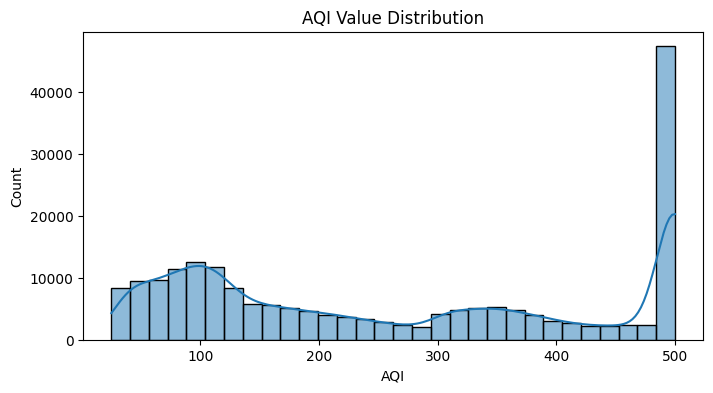

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df['aqi'], bins=30, kde=True)
plt.title("AQI Value Distribution")
plt.xlabel("AQI")
plt.ylabel("Count")
plt.show()

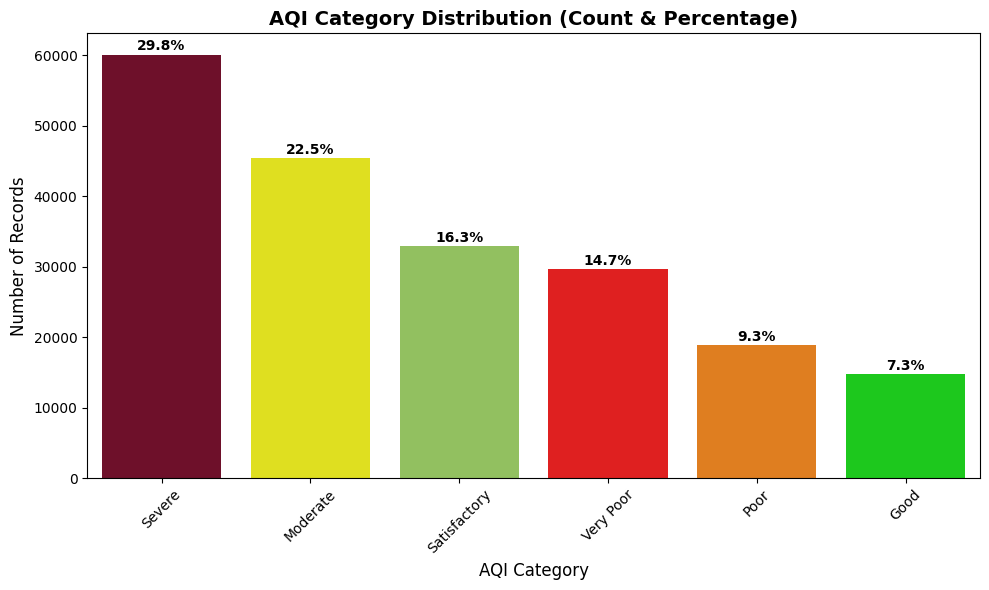

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data
# Get counts and percentages
category_counts = df['aqi_category'].value_counts()
category_percent = df['aqi_category'].value_counts(normalize=True) * 100

# Define a color palette that matches AQI standards for better visualization
aqi_colors = {
    'Good': '#00e400',          # Green
    'Satisfactory': '#92d050',  # Light Green
    'Moderate': '#ffff00',      # Yellow
    'Poor': '#ff7e00',          # Orange
    'Very Poor': '#ff0000',     # Red
    'Severe': '#7e0023'         # Dark Red/Maroon
}

# 2. Create Plot
plt.figure(figsize=(10, 6))

# Use 'hue' to avoid the palette warning and 'palette' for custom AQI colors
sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    palette=aqi_colors,
    hue=category_counts.index,
    legend=False
)

# 3. Add Labels and Titles
plt.title("AQI Category Distribution (Count & Percentage)", fontsize=14, fontweight='bold')
plt.xlabel("AQI Category", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.xticks(rotation=45)

# 4. Add Percentage Labels on top (Fixed with .iloc to remove FutureWarning)
for i, v in enumerate(category_counts.values):
    # Using .iloc[i] ensures we access by position correctly
    percent = category_percent.iloc[i]
    plt.text(i, v + (max(category_counts.values) * 0.01), f"{percent:.1f}%",
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

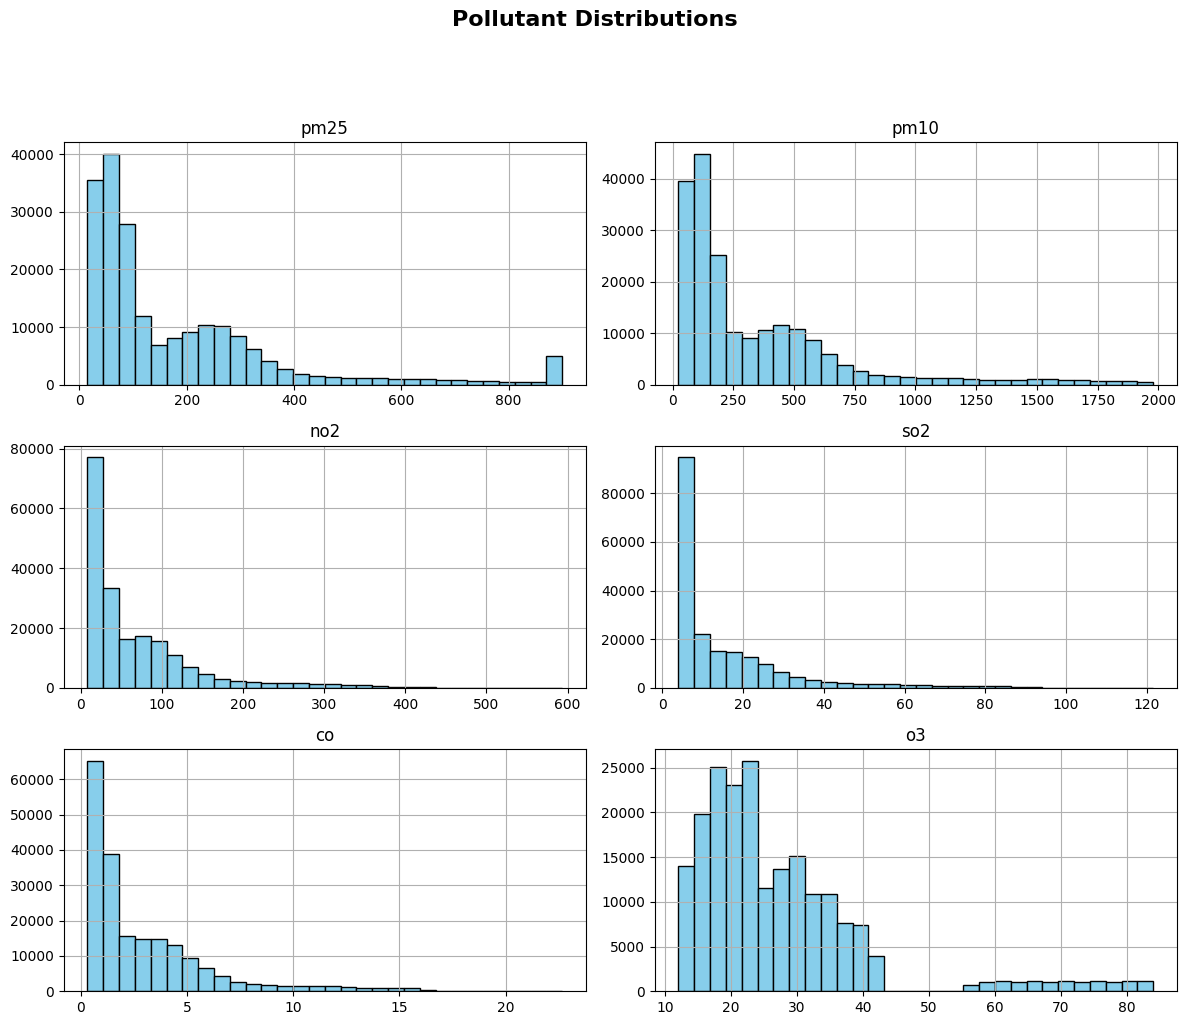

In [14]:
import matplotlib.pyplot as plt

# Define pollutants
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

# 1. Plot the histograms
# 'edgecolor' makes the bins distinct and readable
df[pollutants].hist(figsize=(12, 10), bins=30, color='skyblue', edgecolor='black')

# 2. Add a main title
plt.suptitle("Pollutant Distributions", fontsize=16, fontweight='bold', y=1.02)

# 3. CRITICAL: Use tight_layout to prevent titles from overlapping
# rect=[0, 0.03, 1, 0.95] ensures the suptitle has its own space at the top
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

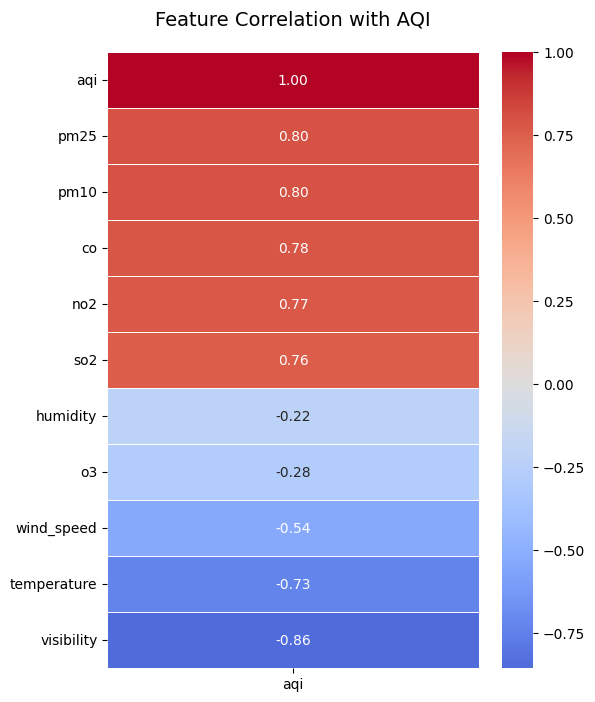

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure columns are sorted for clarity
important_cols = available_pollutants + available_weather
corr_matrix = df[important_cols + ['aqi']].corr()
aqi_corr_sorted = corr_matrix[['aqi']].sort_values(by='aqi', ascending=False)

plt.figure(figsize=(6, 8)) # Increased height slightly for better readability

sns.heatmap(
    aqi_corr_sorted,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0,       # Highlights the 0-point (neutral correlation)
    linewidths=0.5  # Adds a slight border between cells for clarity
)

plt.title("Feature Correlation with AQI", fontsize=14, pad=20)
plt.show()

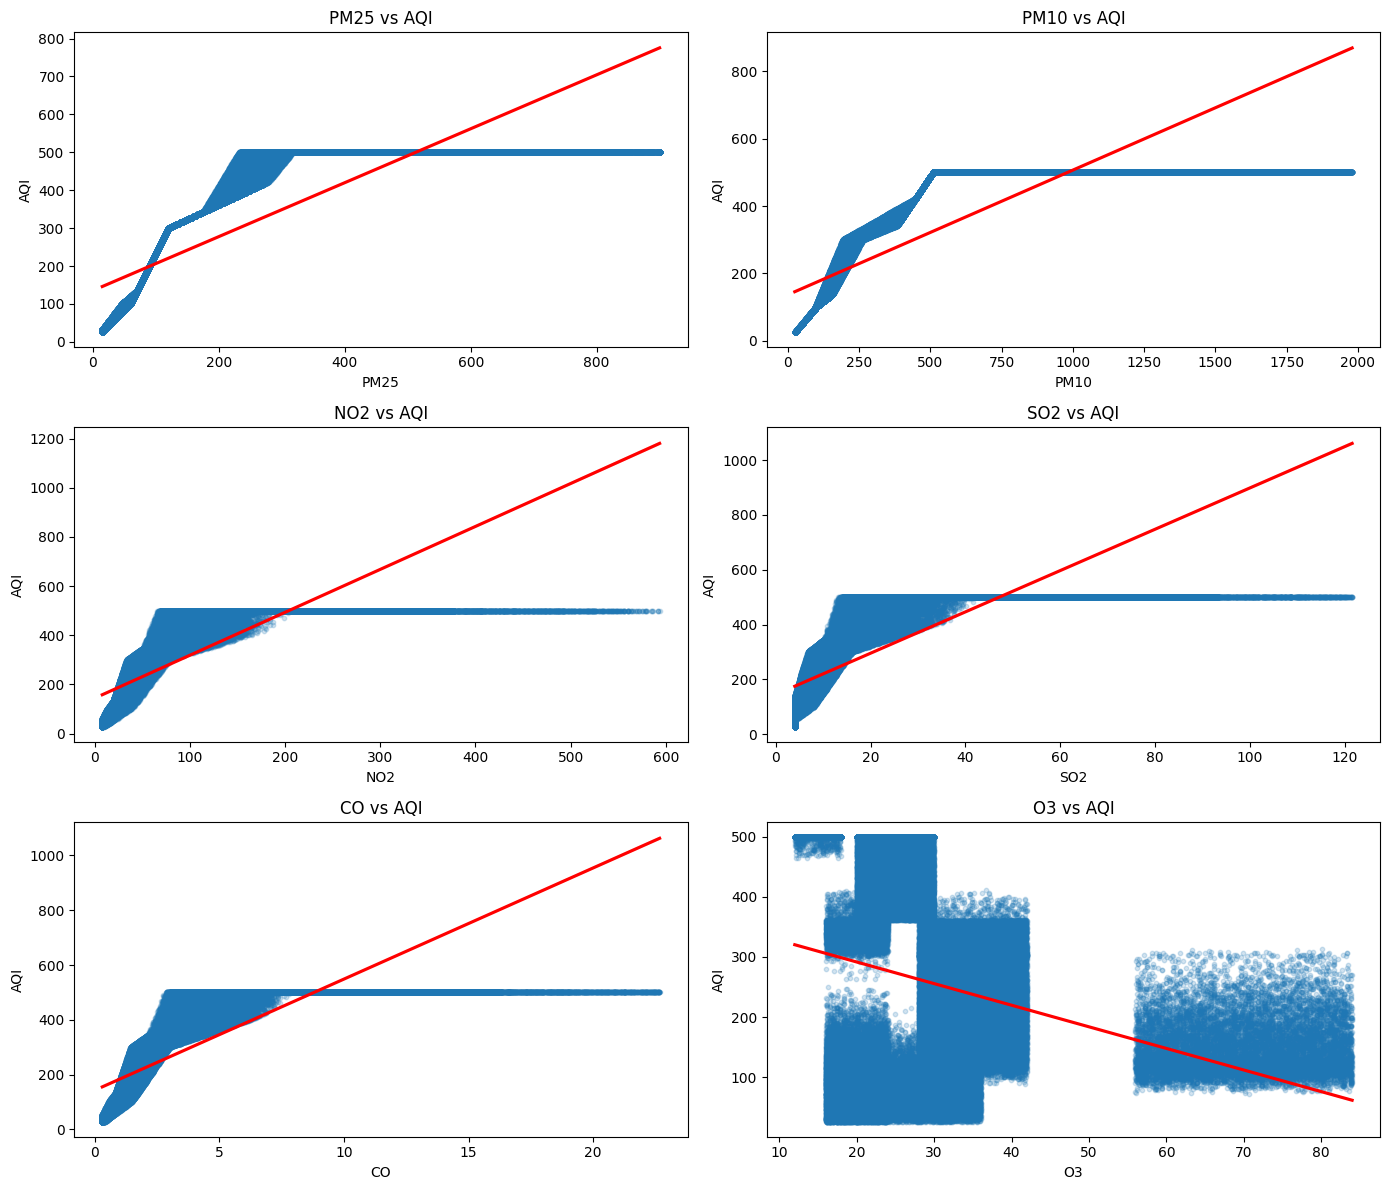

In [16]:
df = pd.read_csv("delhi_ncr_aqi_dataset.csv")  # use correct file path
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Force interactive mode (helps trigger the window in some IDEs)
plt.ion()

pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

# 2. Setup the figure
fig = plt.figure(figsize=(14, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(3, 2, i)
    # Using regplot helps visualize the trend line through the "cloud" of data
    sns.regplot(x=df[col], y=df['aqi'], scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})
    plt.title(f"{col.upper()} vs AQI")
    plt.xlabel(col.upper())
    plt.ylabel("AQI")

plt.tight_layout()

# 3. Explicitly call draw and show
plt.draw()
plt.show(block=True) # block=True keeps the window open until you close it

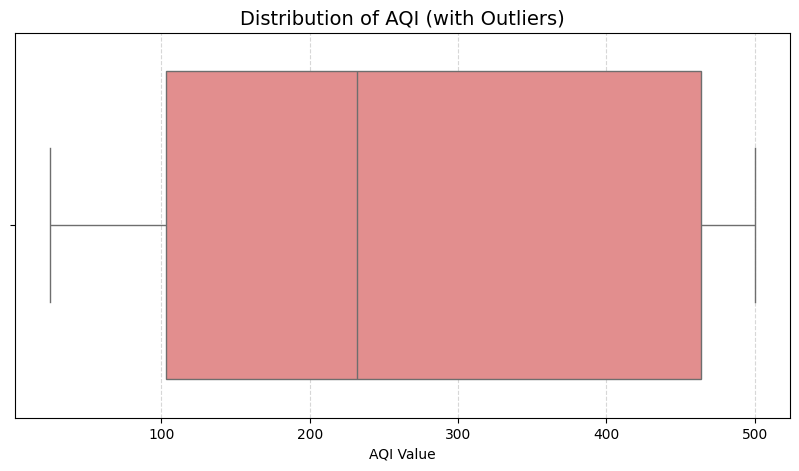

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Using Seaborn for a more modern look
# 'fliersize=1' makes the outlier dots smaller so the plot is less cluttered
sns.boxplot(x=df['aqi'], color='lightcoral', fliersize=1)

plt.title("Distribution of AQI (with Outliers)", fontsize=14)
plt.xlabel("AQI Value")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

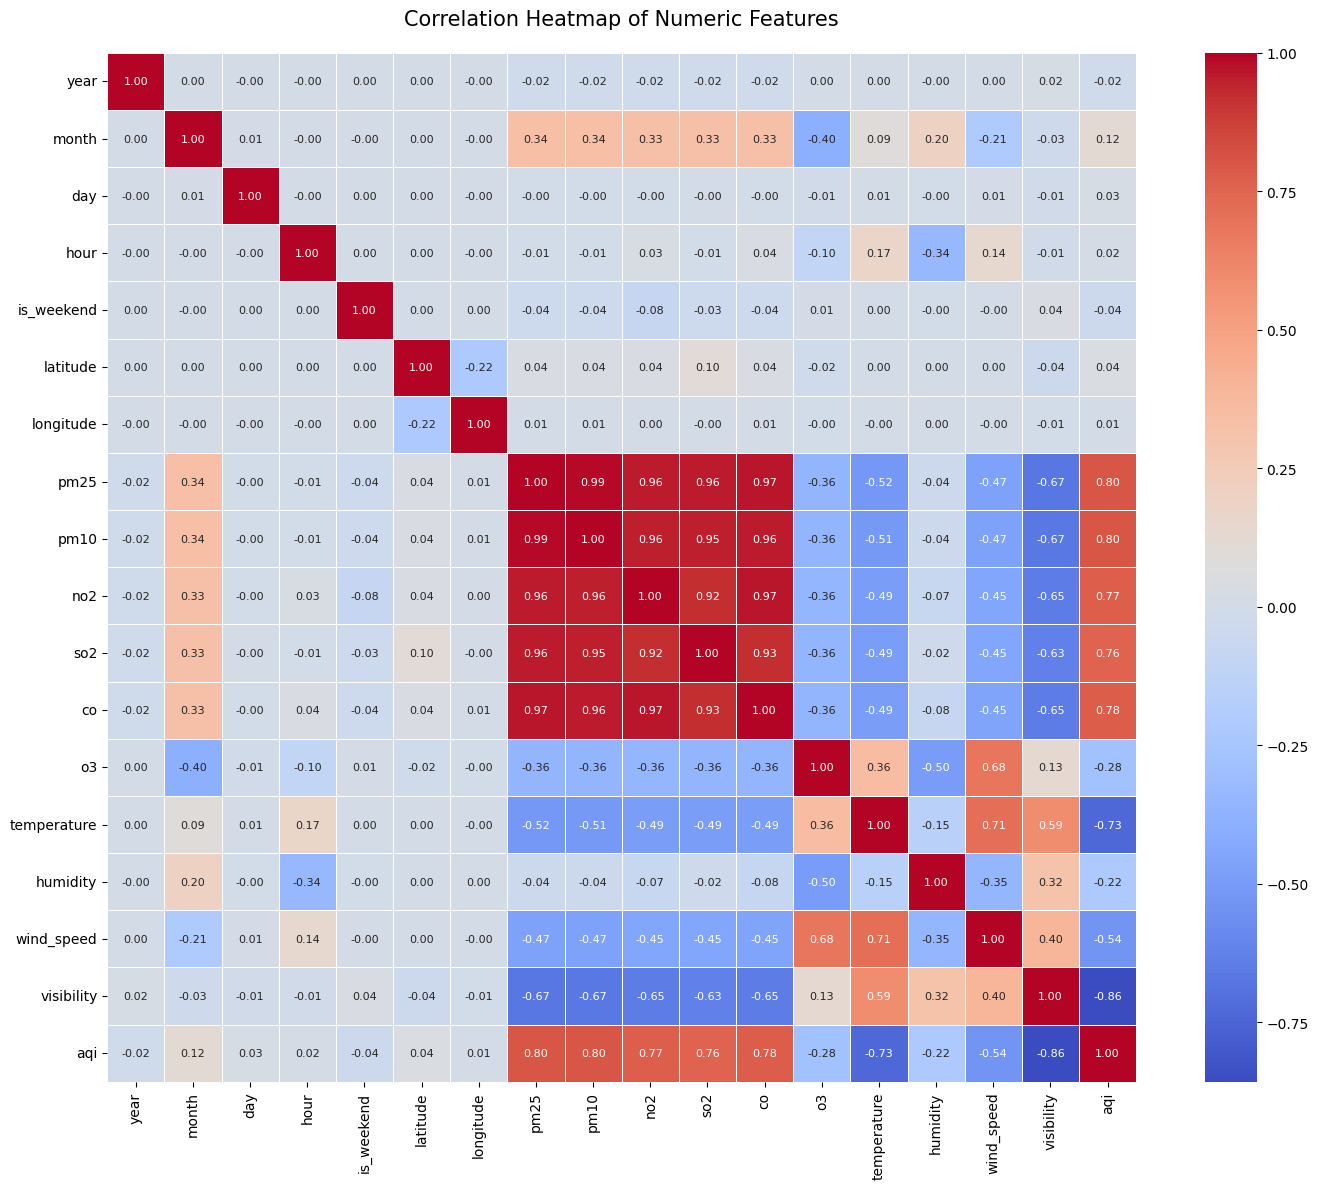

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# 2. Check if we have enough columns to make a meaningful heatmap
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(15, 12)) # Large size for 18 columns

    corr = numeric_df.corr()

    # 3. Create Heatmap
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        square=True,
        annot_kws={"size": 8}, # Smaller font for annotations so they don't overlap
        linewidths=0.5
    )

    plt.title('Correlation Heatmap of Numeric Features', fontsize=15, pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for a heatmap.")

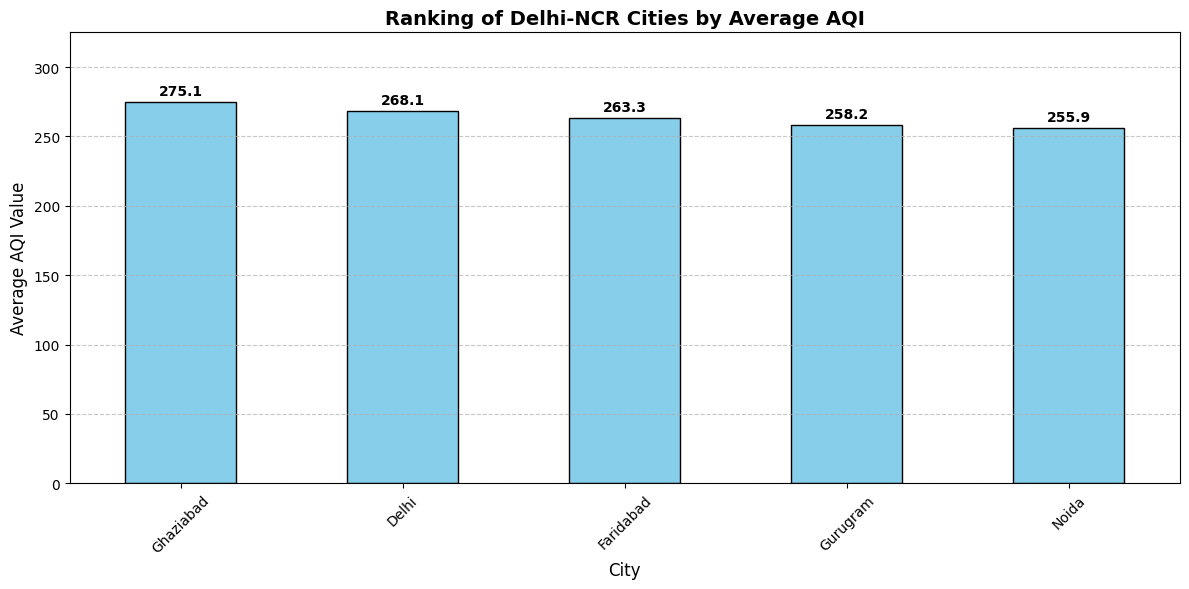

In [19]:
city_aqi = df_clean.groupby('city')['aqi'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

# Plotting
ax = city_aqi.plot(kind='bar', color='skyblue', edgecolor='black')

# Add the numeric labels on top of each bar
for i, v in enumerate(city_aqi):
    ax.text(i, v + 5, f"{v:.1f}", ha='center', fontweight='bold')

plt.title("Ranking of Delhi-NCR Cities by Average AQI", fontsize=14, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Average AQI Value", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, city_aqi.max() + 50) # Give some space for the labels
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

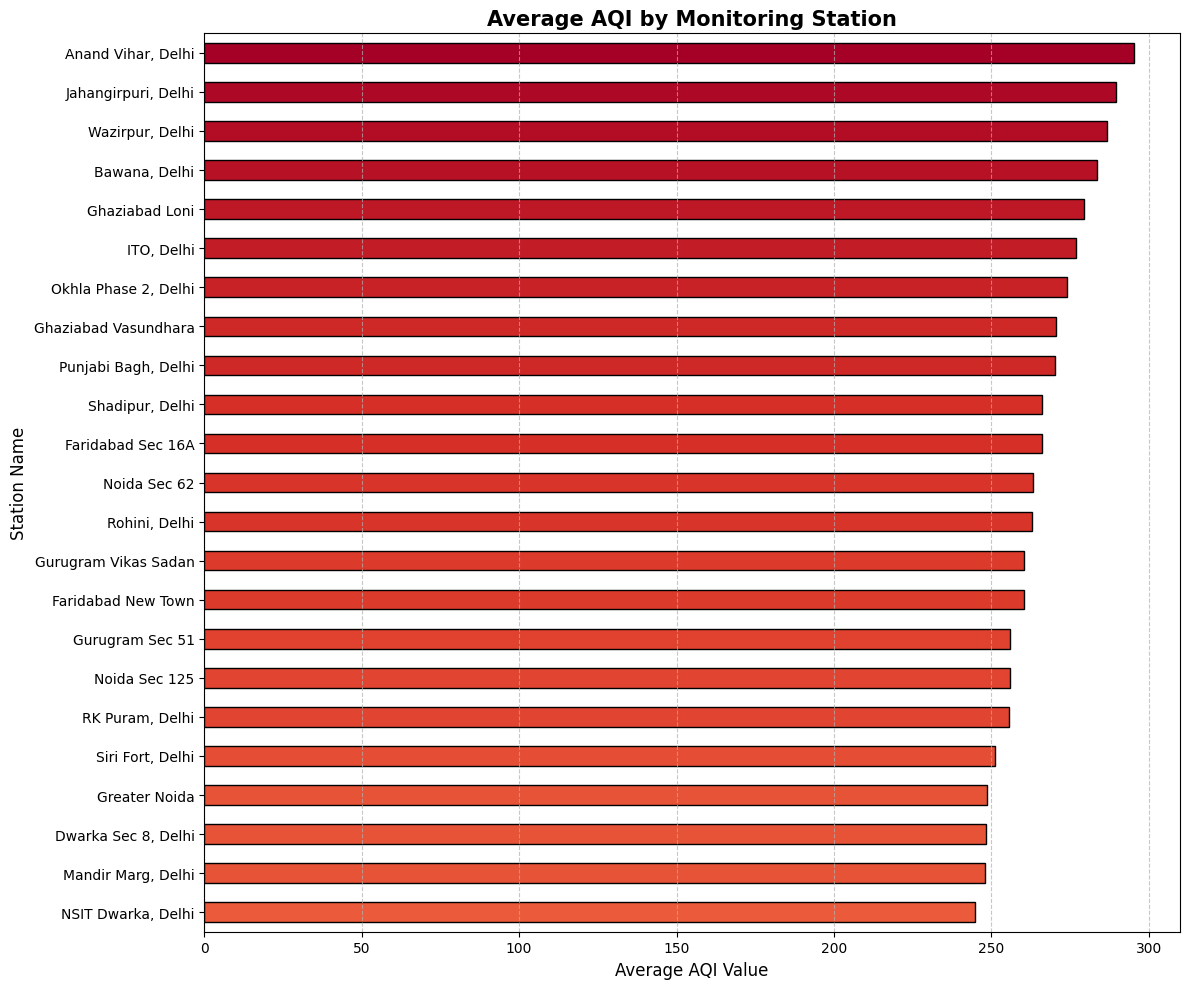

In [20]:
# Calculate mean and sort
station_aqi = df_clean.groupby('station')['aqi'].mean().sort_values()

# Increase height (10) to accommodate all 23 stations
plt.figure(figsize=(12, 10))

# Using a color map to highlight the intensity
colors = plt.cm.RdYlGn_r(station_aqi / station_aqi.max()) # Red for high, Green for low
station_aqi.plot(kind='barh', color=colors, edgecolor='black')

plt.title("Average AQI by Monitoring Station", fontsize=15, fontweight='bold')
plt.xlabel("Average AQI Value", fontsize=12)
plt.ylabel("Station Name", fontsize=12)

# Add a grid on the X-axis to make it easier to trace the values
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

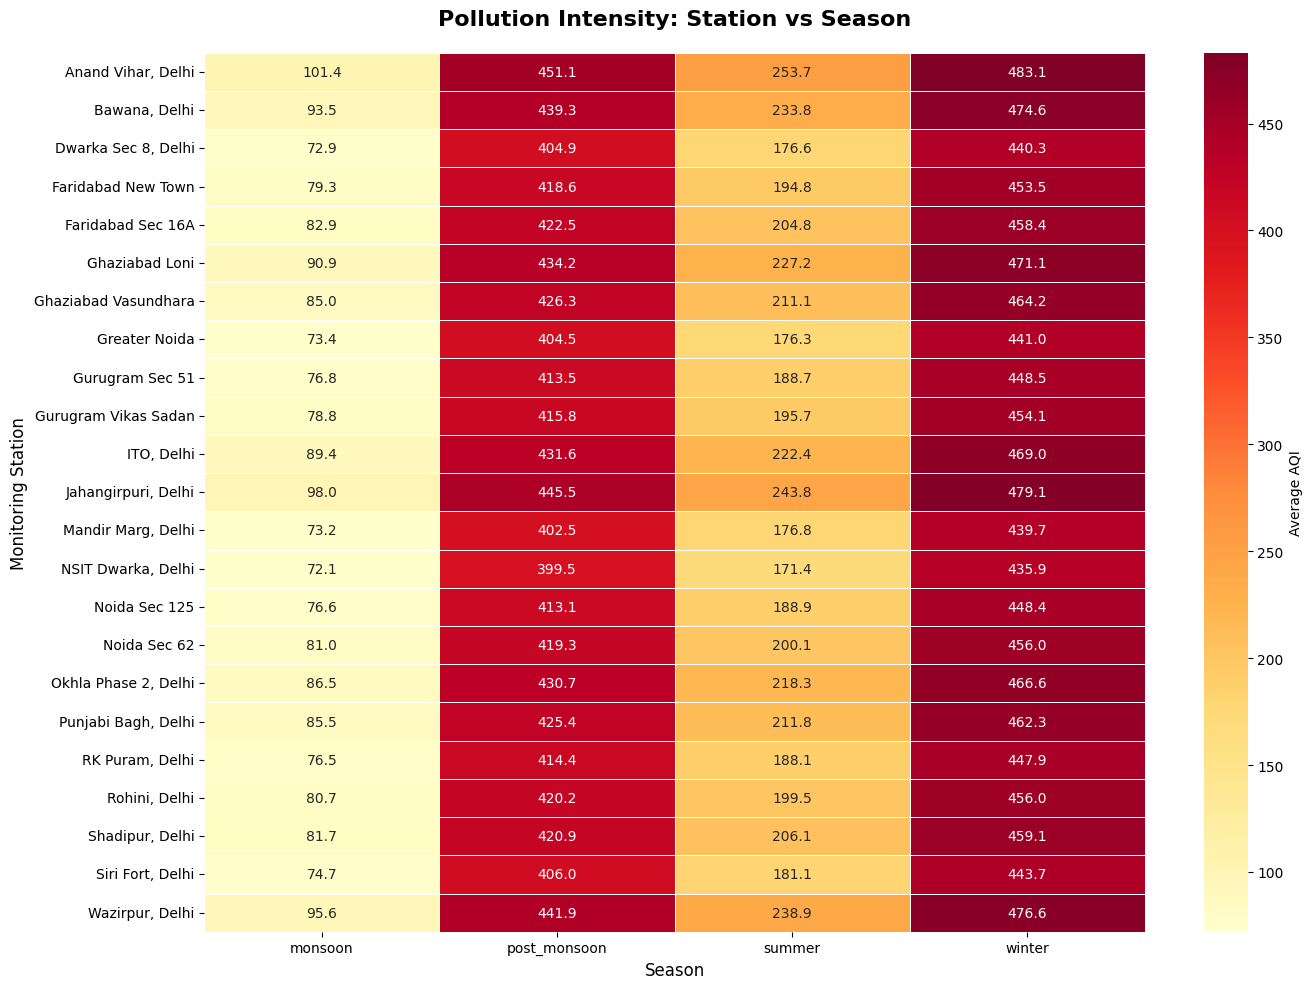

In [21]:
# Create the pivot table
state_season = df_clean.pivot_table(
    values='aqi',
    index='station',
    columns='season',
    aggfunc='mean'
)

# Reorder columns to follow a natural seasonal flow if desired
# seasons_order = ['spring', 'summer', 'monsoon', 'winter']
# state_season = state_season.reindex(columns=seasons_order)

plt.figure(figsize=(14, 10))

# Improvements:
# 1. 'YlOrRd' (Yellow-Orange-Red) provides better contrast than just 'Reds'
# 2. 'fmt=".1f"' keeps the numbers clean (one decimal place)
# 3. 'linewidths' helps separate the "tiles"
sns.heatmap(state_season,
            annot=True,
            cmap='YlOrRd',
            fmt='.1f',
            linewidths=0.5,
            cbar_kws={'label': 'Average AQI'})

plt.title("Pollution Intensity: Station vs Season", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Monitoring Station", fontsize=12)
plt.xlabel("Season", fontsize=12)

plt.tight_layout()
plt.show()

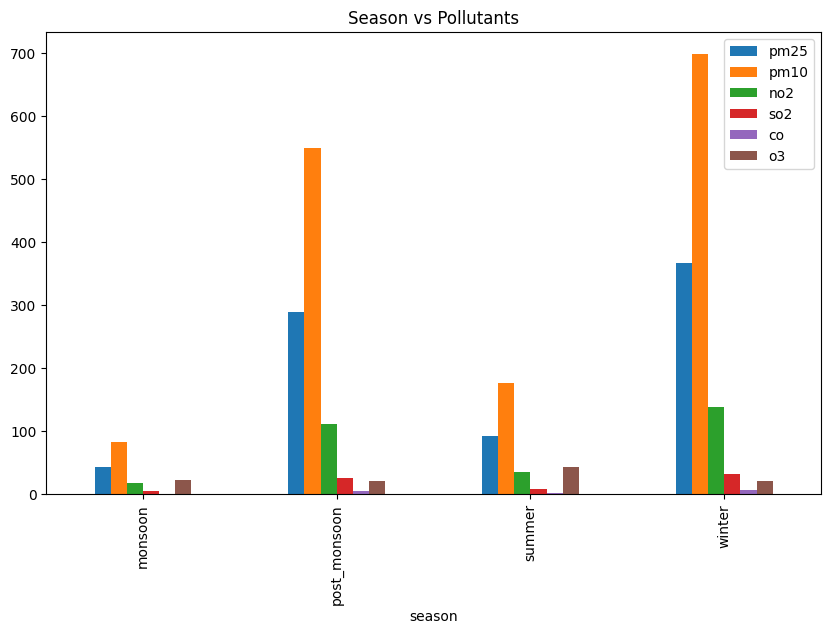

In [22]:
#Konsa pollutant konse season mein peak krta hai
season_pollutant = df.groupby("season")[pollutants].mean()

season_pollutant.plot(kind="bar", figsize=(10,6))
plt.title("Season vs Pollutants")
plt.show()

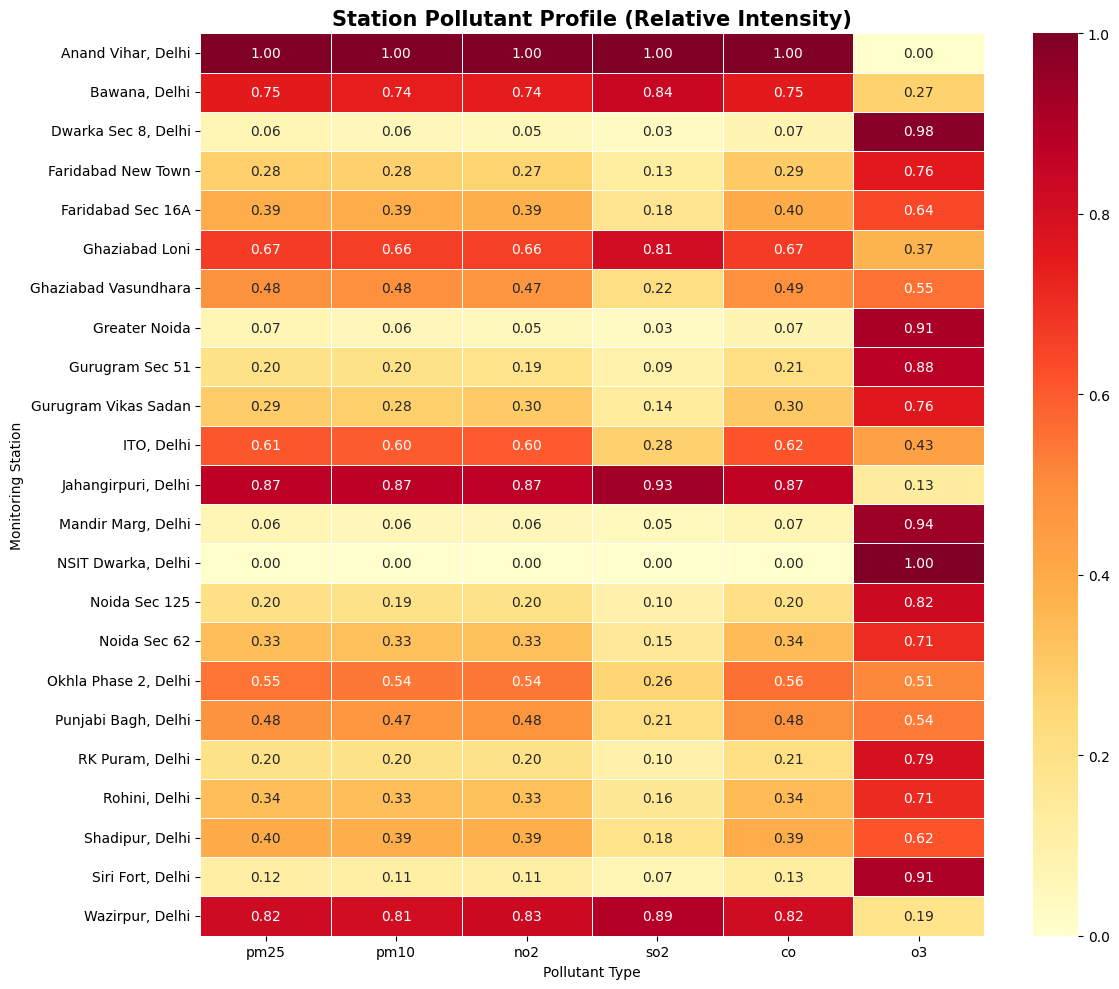

In [23]:
# 1. Calculate the mean per station
station_pollution = df.groupby("station")[pollutants].mean()

# 2. Normalize the data (Min-Max Scaling)
# This makes every pollutant range from 0 to 1 so they can be compared fairly
station_pollution_scaled = (station_pollution - station_pollution.min()) / (station_pollution.max() - station_pollution.min())

plt.figure(figsize=(12, 10))

# 3. Create Heatmap
sns.heatmap(station_pollution_scaled,
            cmap="YlOrRd",    # Yellow to Red is often better for pollution
            annot=True,        # Set to True if you want to see the 0-1 scores
            fmt=".2f",
            linewidths=0.5)

plt.title("Station Pollutant Profile (Relative Intensity)", fontsize=15, fontweight='bold')
plt.xlabel("Pollutant Type")
plt.ylabel("Monitoring Station")

plt.tight_layout()
plt.show()

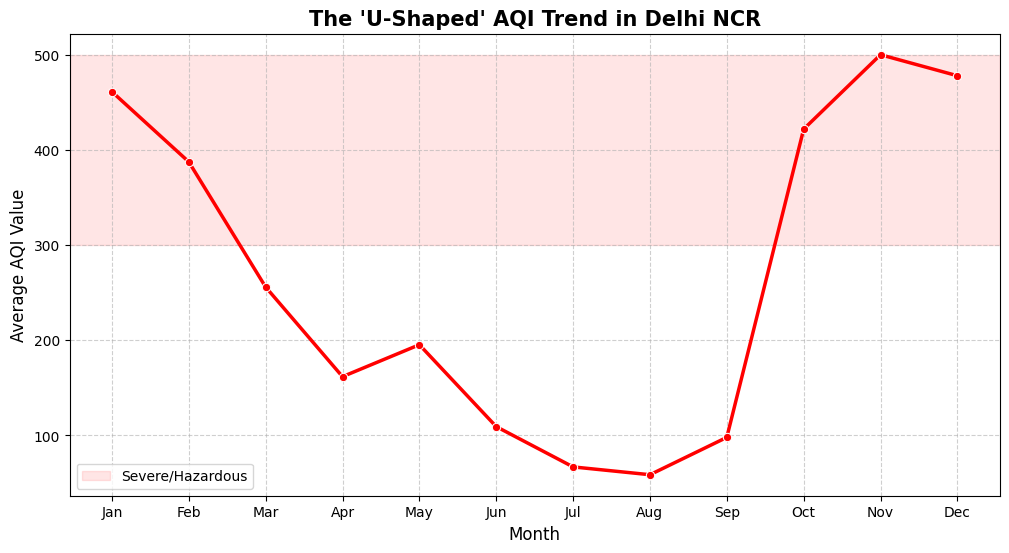

In [24]:
import calendar
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by numeric month first to keep the order
monthly_aqi = df.groupby('month')['aqi'].mean().reset_index()

# 2. Map the names (1 -> Jan, 2 -> Feb, etc.)
monthly_aqi['month_name'] = monthly_aqi['month'].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(12, 6))

# 3. Use 'sort=False' in lineplot to respect the dataframe's row order (1 to 12)
sns.lineplot(data=monthly_aqi, x='month_name', y='aqi', marker='o', sort=False, color='red', linewidth=2.5)

# 4. Add a shaded area to emphasize the "Danger Zone" (AQI > 300)
plt.axhspan(300, 500, color='red', alpha=0.1, label='Severe/Hazardous')

plt.title("The 'U-Shaped' AQI Trend in Delhi NCR", fontsize=15, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average AQI Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

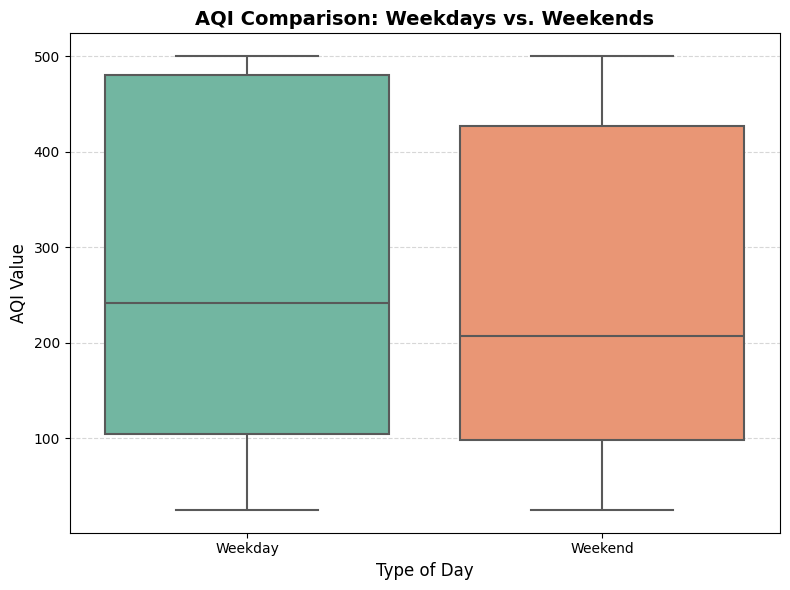

day_type
Weekday    242.0
Weekend    207.0
Name: aqi, dtype: float64


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply your logic
df['day_type'] = df['day_of_week'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

plt.figure(figsize=(8, 6))

# 2. Add 'hue' for better colors and 'fliersize' to handle 200k outlier dots cleanly
sns.boxplot(
    data=df,
    x='day_type',
    y='aqi',
    palette='Set2',
    hue='day_type',
    fliersize=1,     # Makes outlier dots smaller/cleaner
    linewidth=1.5
)

plt.title("AQI Comparison: Weekdays vs. Weekends", fontsize=14, fontweight='bold')
plt.xlabel("Type of Day", fontsize=12)
plt.ylabel("AQI Value", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. Quick statistical check to confirm the visual
print(df.groupby('day_type')['aqi'].median())

In [26]:
# Remove rows where target (aqi) is missing
df = df.dropna(subset=['aqi'])

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Dataset Loading (Make sure the filename is correct)
df = pd.read_csv('delhi_ncr_aqi_dataset.csv')

# 2. Preprocessing: Drop rows where AQI is missing
df = df.dropna(subset=['aqi'])

# 3. Features and Target selection
# Hum sirf weather-based features use kar rahe hain jaisa tumne kaha
features = ['temperature', 'humidity', 'wind_speed', 'visibility']
X = df[features]
y = df['aqi']

# 4. Train-Test Split with FIXED random_state
# random_state=42 ensures the data split is always the same
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Scaling with FIXED parameters
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# MODEL 1: LINEAR REGRESSION
# ---------------------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# ---------------------------------------------------------
# MODEL 2: XGBOOST (With fixed parameters for consistency)
# ---------------------------------------------------------
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,    # Ye sabse important hai consistency ke liye
    n_jobs=-1,
    objective='reg:squarederror'
)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

# ---------------------------------------------------------
# EVALUATION & COMPARISON
# ---------------------------------------------------------
results = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost'],
    'MAE': [mean_absolute_error(y_test, lr_preds), mean_absolute_error(y_test, xgb_preds)],
    'R2 Score': [r2_score(y_test, lr_preds), r2_score(y_test, xgb_preds)]
})

print("\n--- Weather Based Comparison ---")
print(results)

# ---------------------------------------------------------
# CONSISTENT PREDICTION FUNCTION
# ---------------------------------------------------------
def predict_aqi(temp, hum, wind, vis):
    # Data ko waisa hi banayein jaisa training mein tha
    input_data = pd.DataFrame([[temp, hum, wind, vis]], columns=features)
    input_scaled = scaler.transform(input_data)

    lr_val = lr_model.predict(input_scaled)[0]
    xgb_val = xgb_model.predict(input_scaled)[0]

    print(f"\nResults for Temp:{temp}, Hum:{hum}, Wind:{wind}, Vis:{vis}")
    print(f"Linear Regression Prediction: {lr_val:.2f}")
    print(f"XGBoost Prediction: {xgb_val:.2f}")

# Test karke dekhte hain
predict_aqi(35, 70, 4, 2)


--- Weather Based Comparison ---
               Model        MAE  R2 Score
0  Linear Regression  57.939833  0.829969
1            XGBoost  25.245449  0.958168

Results for Temp:35, Hum:70, Wind:4, Vis:2
Linear Regression Prediction: 307.35
XGBoost Prediction: 274.50


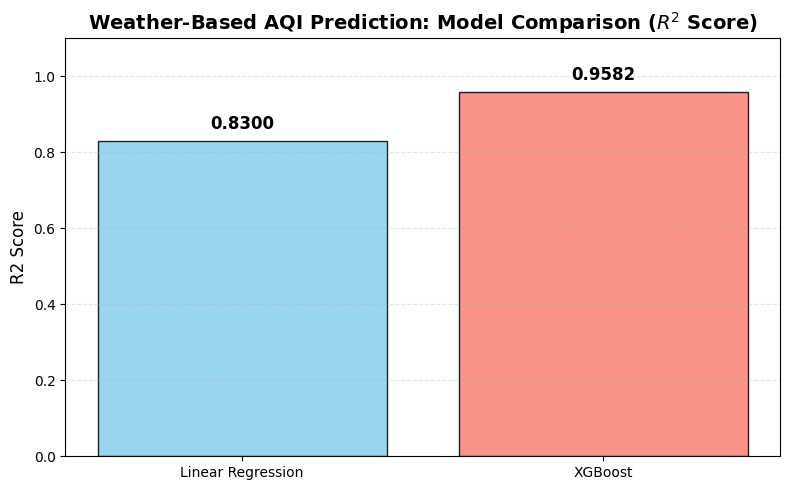

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Metrics calculate karna
lr_r2 = r2_score(y_test, lr_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

# 2. Plotting ke liye data prepare karna
models_list = ['Linear Regression', 'XGBoost']
r2_vals = [lr_r2, xgb_r2]

# 3. Figure Setup
plt.figure(figsize=(8, 5))

# 4. Bar Chart banana
# Palette se colors fix kar diye hain (Blue aur Green/Red combo)
bars = plt.bar(models_list, r2_vals, color=['skyblue', 'salmon'], edgecolor='black', alpha=0.85)

# 5. Graph Aesthetics
plt.title("Weather-Based AQI Prediction: Model Comparison ($R^2$ Score)", fontsize=14, fontweight='bold')
plt.ylabel("R2 Score", fontsize=12)
plt.ylim(0, 1.1)  # Taki bars ke upar space rahe labels ke liye
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 6. Bars ke upar exact Values likhna (Jaise screenshot mein hota hai)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.02,
             f"{yval:.4f}",
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
df['aqi_next_day'] = df['aqi'].shift(-1)

In [30]:
# Bahut zaroori: Shift karne se aakhri row NaN ho jati hai, usey remove karein
df = df.dropna(subset=['aqi_next_day'])

In [31]:
features = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

X = df[features]
y = df['aqi_next_day']

In [32]:
split_index = int(len(df) * 0.8)

X_train_r = X.iloc[:split_index]
X_test_r  = X.iloc[split_index:]

y_train_r = y.iloc[:split_index]
y_test_r  = y.iloc[split_index:]

In [33]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_r, y_train_r)

LinearRegression()

In [34]:
lr_pred = lr.predict(X_test_r)

In [35]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Check karein ki y_test_r mein NaN toh nahi
if np.isnan(y_test_r).any() or np.isnan(lr_pred).any():
    print("Warning: NaN values found in targets or predictions. Cleaning them now...")

    # Sirf wahi indices rakhein jahan values NaN nahi hain
    mask = ~np.isnan(y_test_r) & ~np.isnan(lr_pred)
    y_test_cleaned = y_test_r[mask]
    lr_pred_cleaned = lr_pred[mask]
else:
    y_test_cleaned = y_test_r
    lr_pred_cleaned = lr_pred

# Ab cleaned data par metrics chalayein
print("---- Linear Regression(Next Day AQI - Pollutants Based)----")
print("MAE:", round(mean_absolute_error(y_test_cleaned, lr_pred_cleaned), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_cleaned, lr_pred_cleaned)), 2))
print("R2 Score:", round(r2_score(y_test_cleaned, lr_pred_cleaned), 4))

---- Linear Regression(Next Day AQI - Pollutants Based)----
MAE: 92.55
RMSE: 111.34
R2 Score: 0.613


In [36]:
import xgboost as xgb

# 1. Initialize the XGBoost Regressor
# n_estimators is the number of trees; learning_rate controls the step size
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# 2. Fit the model
xgb_model.fit(X_train_r, y_train_r)

# 3. Make predictions
xgb_pred = xgb_model.predict(X_test_r)

In [37]:
# Check for NaNs (using your existing logic)
if np.isnan(y_test_r).any() or np.isnan(xgb_pred).any():
    mask = ~np.isnan(y_test_r) & ~np.isnan(xgb_pred)
    y_test_cleaned = y_test_r[mask]
    xgb_pred_cleaned = xgb_pred[mask]
else:
    y_test_cleaned = y_test_r
    xgb_pred_cleaned = xgb_pred

# Print Metrics
print("---- XGBoost Regressor (Next Day AQI - Pollutants Based) ----")
print("MAE:", round(mean_absolute_error(y_test_cleaned, xgb_pred_cleaned), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_cleaned, xgb_pred_cleaned)), 2))
print("R2 Score:", round(r2_score(y_test_cleaned, xgb_pred_cleaned), 4))

---- XGBoost Regressor (Next Day AQI - Pollutants Based) ----
MAE: 28.82
RMSE: 39.15
R2 Score: 0.9521


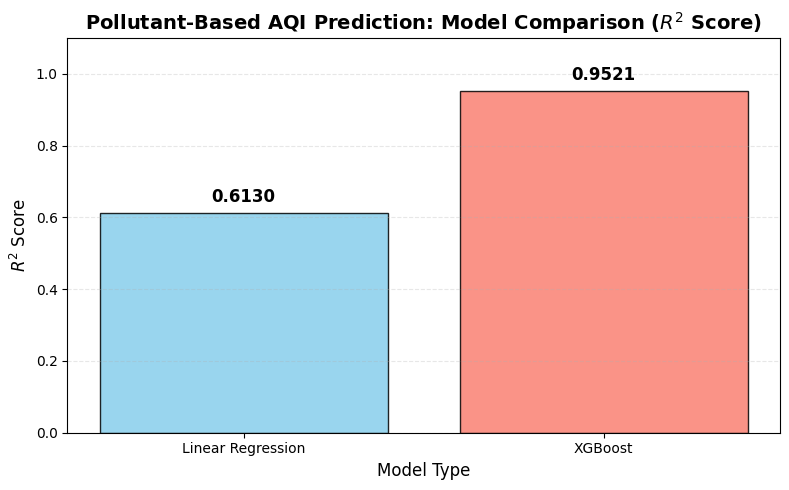

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 1. Calculate R2 Scores using the cleaned test data and predictions
# Note: Using 'y_test_cleaned', 'lr_pred_cleaned', and 'xgb_pred_cleaned' from previous steps
lr_r2 = r2_score(y_test_cleaned, lr_pred_cleaned)
xgb_r2 = r2_score(y_test_cleaned, xgb_pred_cleaned)

# 2. Prepare data for plotting
models_list = ['Linear Regression', 'XGBoost']
r2_vals = [lr_r2, xgb_r2]

# 3. Figure Setup
plt.figure(figsize=(8, 5))

# 4. Create the Bar Chart
# Using Skyblue for Linear and Salmon for XGBoost
bars = plt.bar(models_list, r2_vals, color=['skyblue', 'salmon'], edgecolor='black', alpha=0.85)

# 5. Graph Aesthetics
plt.title("Pollutant-Based AQI Prediction: Model Comparison ($R^2$ Score)", fontsize=14, fontweight='bold')
plt.ylabel("$R^2$ Score", fontsize=12)
plt.xlabel("Model Type", fontsize=12)
plt.ylim(0, 1.1)  # Provides space for text labels above bars
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 6. Add exact values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.02,
             f"{yval:.4f}",
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
# In a local notebook, use plt.show(). Here, we save the file:
plt.savefig('r2_comparison_pollutants.png')

In [39]:
import pandas as pd

# Define a sample input (Current Day Pollutants)
# These values are based on typical units (µg/m³ or mg/m³ for CO)
sample_pollutants = {
    'pm25': 120.5,  # High PM2.5
    'pm10': 210.2,  # High PM10
    'no2': 45.3,    # Moderate NO2
    'so2': 12.1,    # Low SO2
    'co': 1.8,      # Moderate CO
    'o3': 35.0      # Low Ozone
}

# Convert to DataFrame (XGBoost expects the same format as training)
sample_df = pd.DataFrame([sample_pollutants])

# Predict using your trained XGBoost model
predicted_aqi = xgb_model.predict(sample_df)[0]

print(f"--- Pollutant-Based Prediction Example ---")
print(f"Input Data: {sample_pollutants}")
print(f"Predicted AQI for Tomorrow: {predicted_aqi:.2f}")

--- Pollutant-Based Prediction Example ---
Input Data: {'pm25': 120.5, 'pm10': 210.2, 'no2': 45.3, 'so2': 12.1, 'co': 1.8, 'o3': 35.0}
Predicted AQI for Tomorrow: 235.76


<Figure size 1000x600 with 0 Axes>

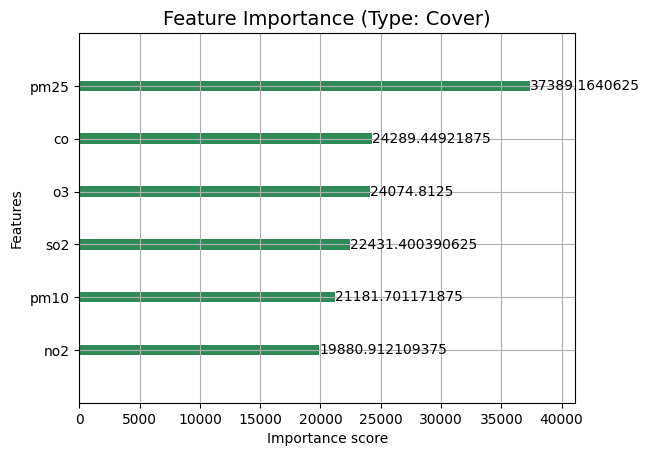

In [40]:
from xgboost import plot_importance

# Plotting with 'cover' instead of 'gain'
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, importance_type='cover', color='seagreen')
plt.title('Feature Importance (Type: Cover)', fontsize=14)
plt.show()

In [41]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Data Selection
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
df_poll = df.dropna(subset=pollutants + ['aqi'])

X_p = df_poll[pollutants]
y_p = df_poll['aqi']

# 2. Split aur Scale
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_p, y_p, test_size=0.2, random_state=42)
scaler_p = StandardScaler()
X_train_p_scaled = scaler_p.fit_transform(X_train_p)
X_test_p_scaled = scaler_p.transform(X_test_p)

# 3. Models Training
lasso_p = Lasso(alpha=1.0).fit(X_train_p_scaled, y_train_p)
ridge_p = Ridge(alpha=1.0).fit(X_train_p_scaled, y_train_p)

# 4. Predictions
lasso_p_preds = lasso_p.predict(X_test_p_scaled)
ridge_p_preds = ridge_p.predict(X_test_p_scaled)

# 5. Metrics Results
print("--- Pollutant Based Performance ---")
print(f"Lasso  | R2 Score: {r2_score(y_test_p, lasso_p_preds):.4f} | MAE: {mean_absolute_error(y_test_p, lasso_p_preds):.2f}")
print(f"Ridge  | R2 Score: {r2_score(y_test_p, ridge_p_preds):.4f} | MAE: {mean_absolute_error(y_test_p, ridge_p_preds):.2f}")

--- Pollutant Based Performance ---
Lasso  | R2 Score: 0.6426 | MAE: 88.72
Ridge  | R2 Score: 0.6438 | MAE: 88.26


In [42]:
# 1. Data Selection
weather_vars = ['temperature', 'humidity', 'wind_speed', 'visibility']
df_weath = df.dropna(subset=weather_vars + ['aqi'])

X_w = df_weath[weather_vars]
y_w = df_weath['aqi']

# 2. Split aur Scale
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.2, random_state=42)
scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

# 3. Models Training
lasso_w = Lasso(alpha=1.0).fit(X_train_w_scaled, y_train_w)
ridge_w = Ridge(alpha=1.0).fit(X_train_w_scaled, y_train_w)

# 4. Predictions
lasso_w_preds = lasso_w.predict(X_test_w_scaled)
ridge_w_preds = ridge_w.predict(X_test_w_scaled)

# 5. Metrics Results
print("\n--- Weather Based Performance ---")
print(f"Lasso  | R2 Score: {r2_score(y_test_w, lasso_w_preds):.4f} | MAE: {mean_absolute_error(y_test_w, lasso_w_preds):.2f}")
print(f"Ridge  | R2 Score: {r2_score(y_test_w, ridge_w_preds):.4f} | MAE: {mean_absolute_error(y_test_w, ridge_w_preds):.2f}")


--- Weather Based Performance ---
Lasso  | R2 Score: 0.8297 | MAE: 58.02
Ridge  | R2 Score: 0.8299 | MAE: 57.94


--- Performance Metrics ---
Pollutants | Lasso R2: 0.6426, MAE: 88.72
Pollutants | Ridge R2: 0.6438, MAE: 88.26
Weather    | Lasso R2: 0.8297, MAE: 58.02
Weather    | Ridge R2: 0.8299, MAE: 57.94


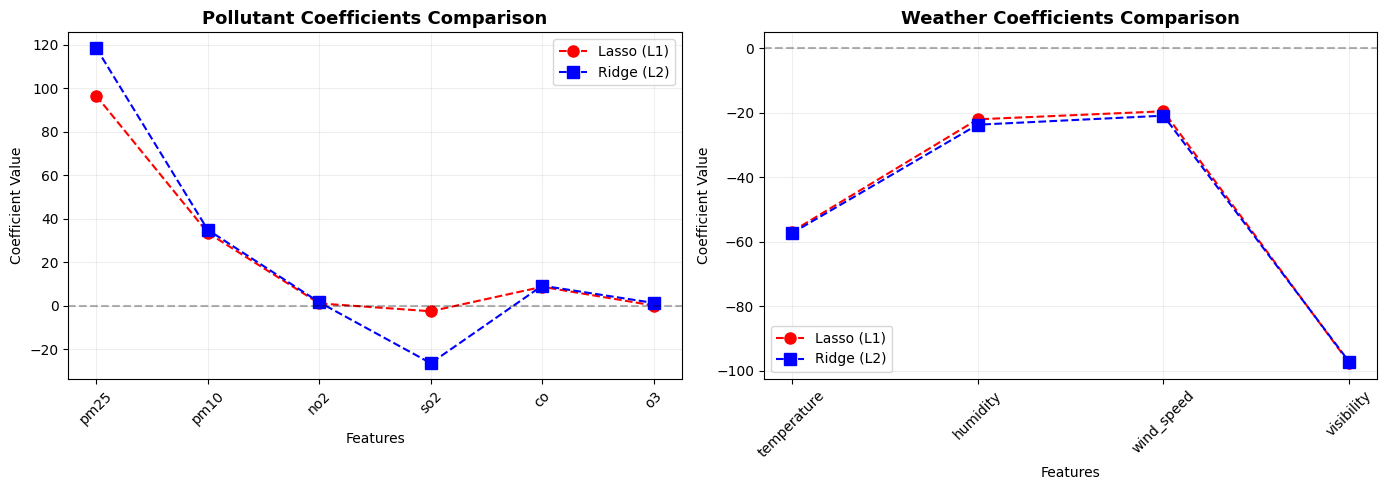

In [43]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: Pollutant-Based Data Preparation ---
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
df_poll = df.dropna(subset=pollutants + ['aqi'])
X_p = df_poll[pollutants]
y_p = df_poll['aqi']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_p, y_p, test_size=0.2, random_state=42)
scaler_p = StandardScaler()
X_train_p_scaled = scaler_p.fit_transform(X_train_p)
X_test_p_scaled = scaler_p.transform(X_test_p)

# Train Models (Pollutants)
lasso_p = Lasso(alpha=1.0).fit(X_train_p_scaled, y_train_p)
ridge_p = Ridge(alpha=1.0).fit(X_train_p_scaled, y_train_p)

# --- STEP 2: Weather-Based Data Preparation ---
weather_vars = ['temperature', 'humidity', 'wind_speed', 'visibility']
df_weath = df.dropna(subset=weather_vars + ['aqi'])
X_w = df_weath[weather_vars]
y_w = df_weath['aqi']

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.2, random_state=42)
scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

# Train Models (Weather)
lasso_w = Lasso(alpha=1.0).fit(X_train_w_scaled, y_train_w)
ridge_w = Ridge(alpha=1.0).fit(X_train_w_scaled, y_train_w)

# --- STEP 3: Print Performance Metrics ---
print("--- Performance Metrics ---")
print(f"Pollutants | Lasso R2: {r2_score(y_test_p, lasso_p.predict(X_test_p_scaled)):.4f}, MAE: {mean_absolute_error(y_test_p, lasso_p.predict(X_test_p_scaled)):.2f}")
print(f"Pollutants | Ridge R2: {r2_score(y_test_p, ridge_p.predict(X_test_p_scaled)):.4f}, MAE: {mean_absolute_error(y_test_p, ridge_p.predict(X_test_p_scaled)):.2f}")
print(f"Weather    | Lasso R2: {r2_score(y_test_w, lasso_w.predict(X_test_w_scaled)):.4f}, MAE: {mean_absolute_error(y_test_w, lasso_w.predict(X_test_w_scaled)):.2f}")
print(f"Weather    | Ridge R2: {r2_score(y_test_w, ridge_w.predict(X_test_w_scaled)):.4f}, MAE: {mean_absolute_error(y_test_w, ridge_w.predict(X_test_w_scaled)):.2f}")

# --- STEP 4: Edited Plotting Code ---
plt.figure(figsize=(14, 5))

# Plot for Pollutants
plt.subplot(1, 2, 1)
plt.plot(pollutants, lasso_p.coef_, 'ro--', label='Lasso (L1)', markersize=8)
plt.plot(pollutants, ridge_p.coef_, 'bs--', label='Ridge (L2)', markersize=8)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Pollutant Coefficients Comparison", fontsize=13, fontweight='bold')
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

# Plot for Weather
plt.subplot(1, 2, 2)
plt.plot(weather_vars, lasso_w.coef_, 'ro--', label='Lasso (L1)', markersize=8)
plt.plot(weather_vars, ridge_w.coef_, 'bs--', label='Ridge (L2)', markersize=8)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Weather Coefficients Comparison", fontsize=13, fontweight='bold')
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

---- Weather Based Classification Results ----
Accuracy Score: 0.7398

Detailed Report:
               precision    recall  f1-score   support

        Good       0.46      0.04      0.07      2905
    Moderate       0.72      0.91      0.81      9083
        Poor       0.66      0.42      0.51      3764
Satisfactory       0.61      0.75      0.67      6438
      Severe       0.87      0.93      0.90     12165
   Very Poor       0.70      0.61      0.65      5978

    accuracy                           0.74     40333
   macro avg       0.67      0.61      0.60     40333
weighted avg       0.72      0.74      0.71     40333



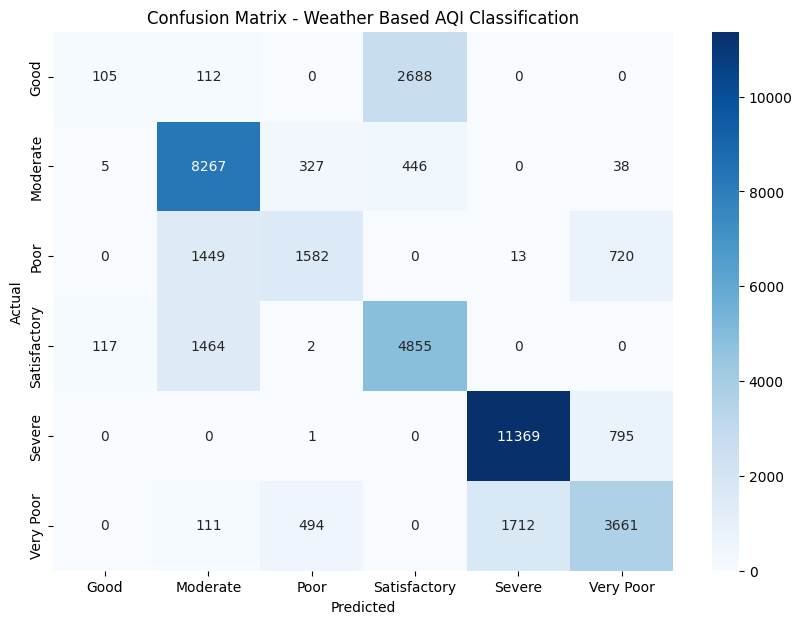

In [44]:
df = pd.read_csv("delhi_ncr_aqi_dataset.csv")  # use correct file path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

# Function to define AQI Categories
def aqi_category(aqi_val):
    if aqi_val <= 50: return "Good"
    elif aqi_val <= 100: return "Satisfactory"
    elif aqi_val <= 200: return "Moderate"
    elif aqi_val <= 300: return "Poor"
    elif aqi_val <= 400: return "Very Poor"
    else: return "Severe"

# Naya column 'aqi_class' banayein
df['aqi_class'] = df['aqi'].apply(aqi_category)
# ---------------------------------------------------------
# SCENARIO A: WEATHER-BASED CLASSIFICATION
# ---------------------------------------------------------
# Sahi columns (temperature, humidity, wind_speed, visibility)
features_w = ['temperature', 'humidity', 'wind_speed', 'visibility']
df_w = df[features_w + ['aqi_class']].dropna()

X_w = df_w[features_w]
y_w = df_w['aqi_class']

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.2, random_state=42)

# Classifier train karna
rf_class_w = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
rf_class_w.fit(X_train_w, y_train_w)

# Prediction & Result
y_pred_w = rf_class_w.predict(X_test_w)

print("---- Weather Based Classification Results ----")
print(f"Accuracy Score: {accuracy_score(y_test_w, y_pred_w):.4f}")
print("\nDetailed Report:\n", classification_report(y_test_w, y_pred_w))

# 4. Confusion Matrix Plot karein (Visualizing Accuracy)
plt.figure(figsize=(10,7))
cm = confusion_matrix(y_test_w, y_pred_w)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_class_w.classes_,
            yticklabels=rf_class_w.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Weather Based AQI Classification')
plt.show()

In [45]:
!pip install folium

In [46]:
# Notebook ke pehle cell mein ye lines add karein
import folium
from folium.features import DivIcon
from folium.plugins import HeatMap
from sklearn.cluster import AgglomerativeClustering

In [47]:
# 1. Clustering Data: Har station ka average profile nikalna
# Hum AQI aur main pollutants (PM2.5, PM10) ke base par cluster karenge
cluster_data = df_clean.groupby('station').agg({
    'aqi': 'mean',
    'pm25': 'mean',
    'pm10': 'mean'
}).reset_index()

# 2. Hierarchical Clustering (Grouping similar pollution zones)
scaler_spatial = StandardScaler()
scaled_vals = scaler_spatial.fit_transform(cluster_data[['aqi', 'pm25', 'pm10']])
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
cluster_data['cluster'] = hc.fit_predict(scaled_vals)

# 3. Final Coordinate Mapping (Aligned with your dataset names)
exact_coords = {
    'Anand Vihar, Delhi': [28.6476, 77.3158], 'Jahangirpuri, Delhi': [28.7328, 77.1706],
    'Wazirpur, Delhi': [28.6997, 77.1654], 'Bawana, Delhi': [28.7762, 77.0510],
    'ITO, Delhi': [28.6286, 77.2410], 'Punjabi Bagh, Delhi': [28.6670, 77.1350],
    'Okhla Phase 2, Delhi': [28.5307, 77.2712], 'Shadipur, Delhi': [28.6515, 77.1503],
    'Rohini, Delhi': [28.7325, 77.1199], 'RK Puram, Delhi': [28.5660, 77.1767],
    'Siri Fort, Delhi': [28.5506, 77.2193], 'Dwarka Sec 8, Delhi': [28.5765, 77.0765],
    'NSIT Dwarka, Delhi': [28.6083, 77.0353], 'Mandir Marg, Delhi': [28.6364, 77.2010],
    'Noida Sec 62': [28.6245, 77.3577], 'Noida Sec 125': [28.5447, 77.3325],
    'Greater Noida': [28.4731, 77.5035], 'Gurugram Vikas Sadan': [28.4506, 77.0270],
    'Gurugram Sec 51': [28.4227, 77.0667], 'Faridabad Sec 16A': [28.4124, 77.3195],
    'Faridabad New Town': [28.3897, 77.3005], 'Ghaziabad Vasundhara': [28.6603, 77.3575],
    'Ghaziabad Loni': [28.7512, 77.2882]
}

# 4. Map initialize karna
m = folium.Map(location=[28.6139, 77.2090], zoom_start=11, tiles='CartoDB dark_matter')

# Heatmap layer add karna
heat_data = [[exact_coords[s][0], exact_coords[s][1], row['aqi']]
             for s, row in cluster_data.set_index('station').iterrows() if s in exact_coords]
HeatMap(heat_data, radius=25, blur=15).add_to(m)

# 5. Legend ka HTML string (Isko hum seedha map mein add karenge)
legend_html = '''
     <div style="position: fixed;
     bottom: 50px; left: 50px; width: 180px; height: 140px;
     background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
     padding: 10px; border-radius: 10px; opacity: 0.8; font-family: Arial;">
     <b>Pollution Zones</b><br>
     <i style="background:#00FF00; border-radius:50%; width:12px; height:12px; display:inline-block"></i> Cluster 0 (Safe)<br>
     <i style="background:#FFFF00; border-radius:50%; width:12px; height:12px; display:inline-block"></i> Cluster 1 (Moderate)<br>
     <i style="background:#FFA500; border-radius:50%; width:12px; height:12px; display:inline-block"></i> Cluster 2 (High)<br>
     <i style="background:#FF4500; border-radius:50%; width:12px; height:12px; display:inline-block"></i> Cluster 3 (Severe)
     </div>
     '''
m.get_root().html.add_child(folium.Element(legend_html))

# 6. Markers aur Labels add karna
cluster_colors = {0: '#00FF00', 1: '#FFFF00', 2: '#FFA500', 3: '#FF4500'}

for _, row in cluster_data.iterrows():
    name = row['station']
    if name in exact_coords:
        loc = exact_coords[name]
        c_color = cluster_colors[row['cluster']]

        folium.CircleMarker(
            location=loc, radius=8, color='white', weight=1,
            fill=True, fill_color=c_color, fill_opacity=0.9,
            popup=f"Station: {name}<br>AQI: {row['aqi']:.1f}"
        ).add_to(m)

        short_name = name.split(',')[0]
        folium.Marker(
            location=[loc[0] + 0.003, loc[1]],
            icon=DivIcon(html=f'<div style="font-size: 9pt; color: {c_color}; font-weight: bold; text-shadow: 1px 1px #000;">{short_name}</div>')
        ).add_to(m)

# Sabse aakhir mein map ko call karein
m

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Clustering ke liye data prepare karna
# Hum har station ke liye mean pollutants nikal rahe hain
station_behavior = df_clean.groupby('station').agg({
    'pm25': 'mean',
    'pm10': 'mean',
    'no2': 'mean',
    'co': 'mean',
    'aqi': 'mean'
}).reset_index()

# 2. Data Scaling (K-Means ke liye zaroori hai)
features_to_cluster = ['pm25', 'pm10', 'no2', 'co']
scaler_km = StandardScaler()
scaled_behavior = scaler_km.fit_transform(station_behavior[features_to_cluster])

# 3. K-Means Model
# Hum 4 clusters le rahe hain: Industrial, High Traffic, Residential, aur Safe Zones
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
station_behavior['cluster_label'] = kmeans.fit_predict(scaled_behavior)

# 4. Clusters ko samajhna (Mapping names for better insight)
# Note: Cluster numbers randomly assign hote hain, hum unke AQI ke base par name denge
cluster_avg_aqi = station_behavior.groupby('cluster_label')['aqi'].mean().sort_values()
cluster_mapping = {
    cluster_avg_aqi.index[0]: "Low Pollution (Residential/Safe)",
    cluster_avg_aqi.index[1]: "Moderate (Mixed Use)",
    cluster_avg_aqi.index[2]: "High (Traffic/Commercial)",
    cluster_avg_aqi.index[3]: "Severe (Industrial/Hotspots)"
}
station_behavior['area_type'] = station_behavior['cluster_label'].map(cluster_mapping)

# 5. Result Dekhte hain
print("--- Station Clustering Results ---")
display(station_behavior[['station', 'aqi', 'area_type']].sort_values(by='aqi', ascending=False))

--- Station Clustering Results ---


,station,aqi,area_type
0,"Anand Vihar, Delhi",295.166857,Severe (Industrial/Hotspots)
11,"Jahangirpuri, Delhi",289.718864,Severe (Industrial/Hotspots)
22,"Wazirpur, Delhi",286.587363,Severe (Industrial/Hotspots)
1,"Bawana, Delhi",283.694685,Severe (Industrial/Hotspots)
5,Ghaziabad Loni,279.569229,High (Traffic/Commercial)
10,"ITO, Delhi",276.974110,High (Traffic/Commercial)
16,"Okhla Phase 2, Delhi",274.130703,High (Traffic/Commercial)
6,Ghaziabad Vasundhara,270.587021,High (Traffic/Commercial)
17,"Punjabi Bagh, Delhi",270.277258,High (Traffic/Commercial)
20,"Shadipur, Delhi",266.125114,Moderate (Mixed Use)


In [49]:
!pip install prophet

In [50]:
!pip install plotly

Agle kuch dinon ki AQI Prediction:
             ds        yhat  yhat_lower  yhat_upper
2217 2026-01-26  440.498999  379.757788  501.428593
2218 2026-01-27  438.150588  375.112177  497.931939
2219 2026-01-28  435.715959  375.618102  497.707211
2220 2026-01-29  434.531808  368.135152  492.488611
2221 2026-01-30  432.570870  376.031222  494.598184


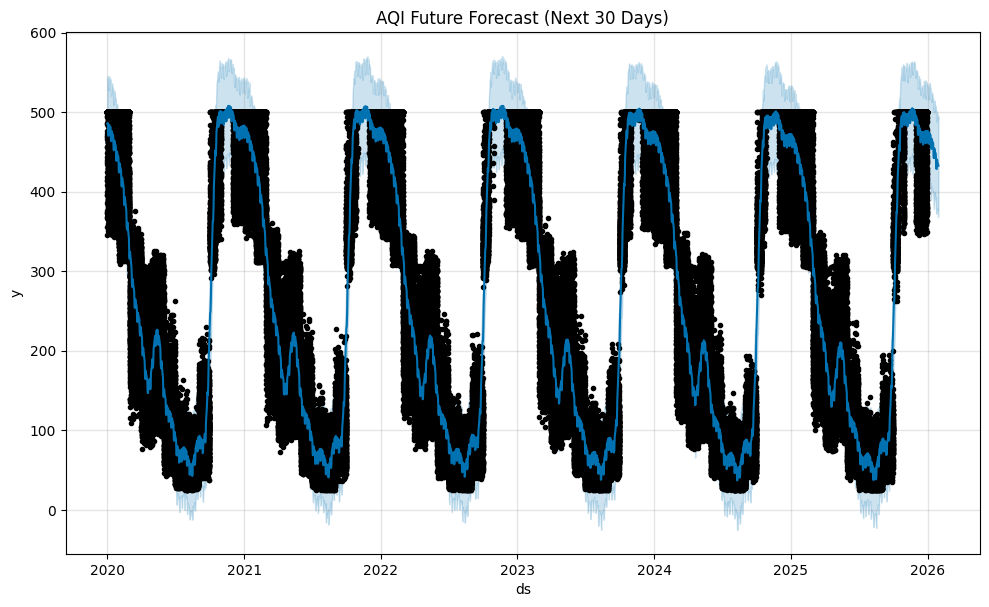

In [51]:
from prophet import Prophet
import pandas as pd

# 1. Data Prepare karein
# Maan lete hain aapke paas 'date' column hai. Agar nahi hai toh index use karein.
df_prophet = df[['date', 'aqi']].copy()
df_prophet.columns = ['ds', 'y'] # Prophet ke liye rename karna zaroori hai

# 2. Model initialize aur train karein
model_forecast = Prophet(yearly_seasonality=True, daily_seasonality=True)
model_forecast.fit(df_prophet)

# 3. Agle 30 dinon ka "future" dataframe banayein
future = model_forecast.make_future_dataframe(periods=30)
forecast = model_forecast.predict(future)

# 4. Results dekhein (Kal ki prediction)
print("Agle kuch dinon ki AQI Prediction:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# 5. Visualizing the Forecast
fig1 = model_forecast.plot(forecast)
plt.title('AQI Future Forecast (Next 30 Days)')
plt.show()

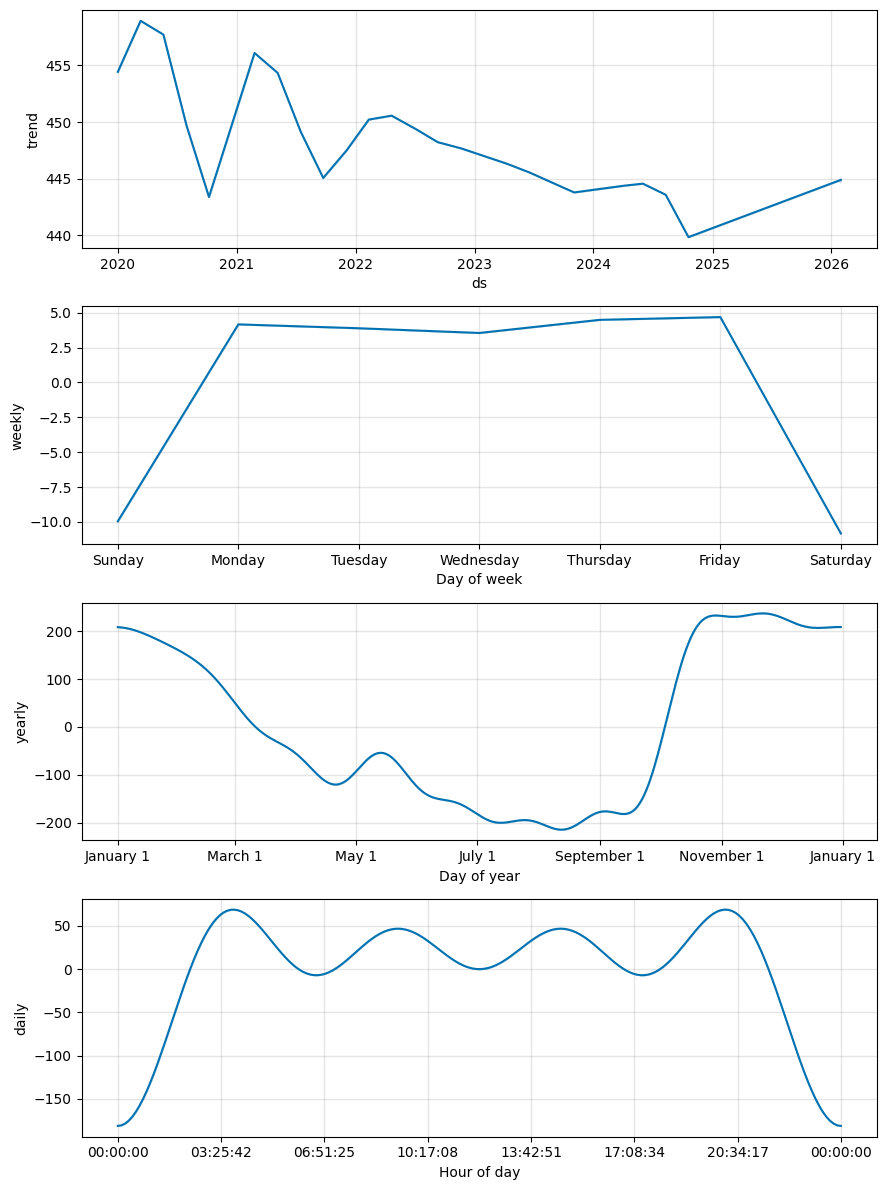

In [52]:
# Trends dikhayega: Weekly, Yearly aur Daily
fig2 = model_forecast.plot_components(forecast)
plt.show()

In [53]:
!pip install tensorflow

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler

# 1. Data Selection & Scaling
# Neural Networks ke liye scaling bahut zaroori hai
features_nn = ['temperature', 'humidity', 'wind_speed', 'visibility']
X_nn = df[features_nn].dropna()
y_nn = df.loc[X_nn.index, 'aqi']

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_nn)
X_test_scaled = scaler.transform(X_test_nn)

# 2. ANN Architecture Build Karna
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)), # Input Layer
    Dropout(0.2), # Overfitting rokne ke liye
    Dense(32, activation='relu'), # Hidden Layer 1
    Dense(16, activation='relu'), # Hidden Layer 2
    Dense(1) # Output Layer (Regression ke liye koi activation nahi)
])

# 3. Compile Model
model.compile(optimizer='adam', loss='mae', metrics=['mse'])

# 4. Model Training
history = model.fit(
    X_train_scaled, y_train_nn,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# 5. Evaluation
nn_preds = model.predict(X_test_scaled)
print(f"\nANN R2 Score: {r2_score(y_test_nn, nn_preds):.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 47.5832 - mse: 5750.4258 - val_loss: 33.6226 - val_mse: 1964.8412
Epoch 2/50
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 36.2177 - mse: 2268.0254 - val_loss: 31.6249 - val_mse: 1784.2094
Epoch 3/50
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 34.3377 - mse: 2042.0372 - val_loss: 30.9169 - val_mse: 1693.8810
Epoch 4/50
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 33.3968 - mse: 1941.3353 - val_loss: 30.4346 - val_mse: 1719.9965
Epoch 5/50
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 32.6639 - mse: 1864.0232 - val_loss: 30.3319 - val_mse: 1644.0479
Epoch 6/50
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 32.1017 - mse: 1818.1447 - val_loss: 30.2271 - val_mse: 1640.2350
Epoch 7/50
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 31.6415 - mse: 1789.7070 - val_loss: 30.2417 - val_mse: 1621.0195
Epoch 8/50
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 31.2364 - mse: 1770.7140 - val_los

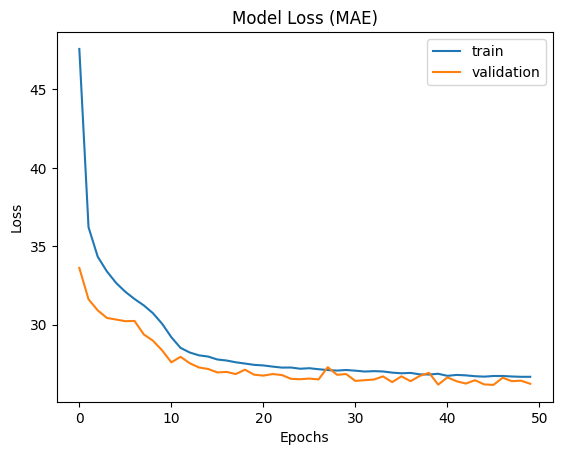

In [55]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Model Loss (MAE)')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

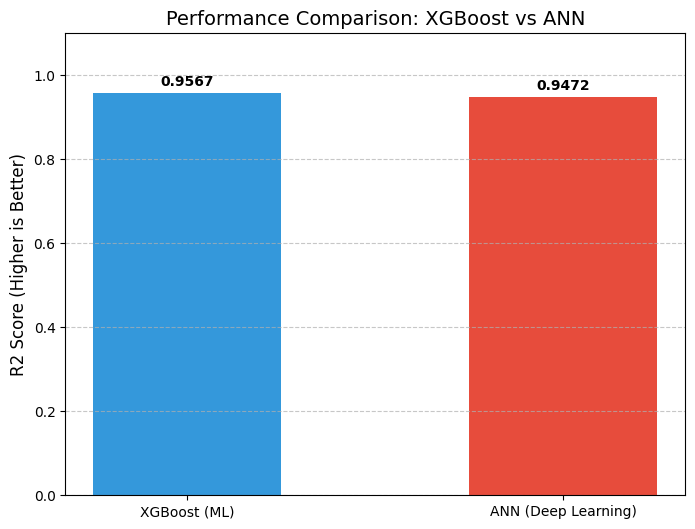

Verdict: XGBoost ne ANN ko 0.0095 score se hara diya!


In [56]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1. XGBoost train karein (Baseline comparison ke liye)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_nn, y_train_nn) # Humne wahi features use kiye jo ANN mein the
xgb_preds = xgb_model.predict(X_test_nn)
xgb_r2 = r2_score(y_test_nn, xgb_preds)

# 2. ANN R2 Score nikaalein (Pichle step se)
# Agar ann_preds already calculate ho chuke hain:
ann_r2 = r2_score(y_test_nn, nn_preds)

# 3. Visualization: Bar Chart Comparison
models = ['XGBoost (ML)', 'ANN (Deep Learning)']
scores = [xgb_r2, ann_r2]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, scores, color=['#3498db', '#e74c3c'], width=0.5)

# Numbers display karne ke liye
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1) # R2 score max 1 hota hai
plt.title('Performance Comparison: XGBoost vs ANN', fontsize=14)
plt.ylabel('R2 Score (Higher is Better)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Final Verdict print karein
if xgb_r2 > ann_r2:
    print(f"Verdict: XGBoost ne ANN ko {(xgb_r2 - ann_r2):.4f} score se hara diya!")
else:
    print(f"Verdict: ANN ne XGBoost ko {(ann_r2 - xgb_r2):.4f} score se hara diya!")